In [1]:
# necessary imports
using PauliPropagation
using Plots
using GLM
using DataFrames
using Logging
using Distributions
using LaTeXStrings
using MLJLinearModels
using MLJBase
using LsqFit

In [2]:
function strict_training_set_generation(layer, dt,J,h,angle_range,num_samples)
    training_thetas_list = Vector{Vector{Float64}}()
    thetas = define_thetas(layer, dt, J, h)
    training_thetas = deepcopy(thetas)
    theta_h_indices = getparameterindices(layer, PauliRotation, [:X])
    for _ in 1:num_samples
        new_tht_h = rand(Uniform(0.0, angle_range))
        training_thetas[theta_h_indices] .= new_tht_h
        push!(training_thetas_list, copy(training_thetas))
    end
    return training_thetas_list
end

strict_training_set_generation (generic function with 1 method)

In [3]:
function kickedisingcircuit(nq, nl; topology=nothing)

    """
    generates a circuit with nq qubits and nl layers where the RX angle is a variable and the RZZ angle is fixed to -π/2
    """
    
    xlayer(circuit) = append!(circuit, (PauliRotation([:X], [qind]) for qind in 1:nq))
    zzlayer(circuit) = append!(circuit, (PauliRotation([:Z, :Z], pair, -π/2) for pair in topology))

    circuit = Gate[]

    for _ in 1:nl
        zzlayer(circuit)
        xlayer(circuit)
    end

    return circuit
end

kickedisingcircuit (generic function with 1 method)

In [4]:
function define_thetas(circuit::Vector{Gate}, dt::Float64, J::Float64=2.0, h::Float64=1.0)
    # get indices indicating which angle corresponds to which gate 
    rzz_indices = getparameterindices(circuit, PauliRotation, [:Z, :Z])
    rx_indices = getparameterindices(circuit, PauliRotation, [:X])
    
    nparams = countparameters(circuit)
    thetas = zeros(nparams)
    
    # following eq. (3)
    thetas[rzz_indices] .= - J * dt * 2
    thetas[rx_indices] .= h * dt * 2

    return thetas
end

define_thetas (generic function with 3 methods)

In [5]:
function training_trotter_time_evolution(
    steps::Int,
    layer::Vector{Gate},
    observable::PauliSum,
    training_thetas::Vector{Vector{Float64}};
    noise=false,
    min_abs_coeff=0.0,
    max_weight=Inf,
    depol_strength=0.02,
    dephase_strength=0.02,
    noise_level=1.0
)
    """
    Computes time evolution trajectories for multiple circuits (parameter sets).
    Returns a matrix of size (n_circuits × (steps + 1)).
    """
    n_circuits = length(training_thetas)
    trajectories = Array{Float64,2}(undef, n_circuits, steps+1)
    for (i, θ) in enumerate(training_thetas)
        trajectories[i, :] = trotter_time_evolution(
            steps, layer, observable, θ;
            noise=noise,
            min_abs_coeff=min_abs_coeff,
            max_weight=max_weight,
            depol_strength=depol_strength,
            dephase_strength=dephase_strength,
            noise_level=noise_level
        )
    end
    return trajectories
end


training_trotter_time_evolution (generic function with 1 method)

In [6]:
function trotter_time_evolution(
    steps::Int64,
    layer::Vector{Gate},
    observable::PauliSum,
    thetas::Vector{Float64};
    noise=false,
    min_abs_coeff=1e-10,
    max_weight = Inf,
    depol_strength=0.02, 
    dephase_strength=0.02,
    noise_level = 1.0
    )

    """
    Function that computes the time evolution of the ansatz using the first order Trotter approximation exact time evolution operator.
    The function returns the overlap of the final state with the |0> state.
    """
    obs = deepcopy(observable)
    expvals_trotter = Float64[]   
    push!(expvals_trotter, overlapwithzero(obs))
    for i in 1:steps
        psum = propagate!(layer, obs, thetas; min_abs_coeff=min_abs_coeff, max_weight=max_weight)
        if noise
            for (pstr, coeff) in psum
                set!(psum, pstr, 
                    coeff*(1-noise_level*depol_strength)^countweight(pstr)*(1-noise_level*dephase_strength)^countxy(pstr))
            end 
        end
        push!(expvals_trotter, overlapwithzero(psum))
    end
    return expvals_trotter  
end

trotter_time_evolution (generic function with 1 method)

In [7]:
function zne(noisy_exp::Vector{Float64}, noise_levels::Vector{Float64}; exact_exp::Union{Nothing, Float64}=nothing)
    model(x, p) = p[1] .+ p[2] .* exp.(-p[3] .* x)
    p0 = [noisy_exp[end], noisy_exp[1] - noisy_exp[end], 1.0]
    fit_ = curve_fit(model, noise_levels, noisy_exp, p0)
    corrected = model(0.0, fit_.param)

    if exact_exp === nothing
        return corrected, nothing, nothing
    end

    abs_error_after = abs(exact_exp - corrected)
    abs_error_before = abs(exact_exp - noisy_exp[1])
    return corrected, abs_error_after, abs_error_before
end


zne (generic function with 1 method)

In [8]:
function vnCDR(
    noisy_exp_values::Array{Float64,2},         # size (m circuits, n+1 noise levels)
    exact_exp_values::Array{Float64,1},         # size m
    noisy_target_exp_value::Array{Float64, 1};  # size n+1
    exact_target_exp_value::Union{Nothing, Float64}=nothing)
    # linear regression
    model = LinearRegressor(fit_intercept = false);

    # Convert input matrix to DataFrame
    params = 0
    # we add the following line to avoid invasing logging information 
    with_logger(Logging.SimpleLogger(stderr, Logging.Warn)) do
        X = DataFrame(noisy_exp_values', :auto)
        mach = machine(model, X, exact_exp_values)
        fit!(mach)
        params = fitted_params(mach)
    end

    # Manually compute prediction
    coefs = [v for (_, v) in params.coefs]
    corrected = coefs'* noisy_target_exp_value

    if exact_target_exp_value === nothing
        return corrected, nothing, nothing
    end

    # absolute errors before and after correction
    abs_error_before = abs(exact_target_exp_value - noisy_target_exp_value[1]) 
    abs_error_after = abs(exact_target_exp_value - corrected)
    
    return corrected, abs_error_after, abs_error_before
end


vnCDR (generic function with 1 method)

In [9]:
function cdr(noisy_exp_values::Array{Float64, 1},
            exact_exp_values::Array{Float64, 1},
            noisy_target_exp_value::Float64;
            exact_target_exp_value::Union{Nothing, Float64}=nothing)
    """
    Function that computes the CDR correction for a single noisy expectation value.
    """
    lin_model(x, p) = p[1] .+ p[2] .* x
    # initial guess of the coefficient
    p0 = [exact_exp_values[1],0.01]
    fit_ = curve_fit(lin_model, noisy_exp_values, exact_exp_values, p0)
    # extrapolate to 0-noise using the fitted model
    corrected = lin_model(noisy_target_exp_value, fit_.param)
    
    if exact_target_exp_value === nothing
        return corrected, nothing, nothing
    end
    
    abs_error_after = abs(exact_target_exp_value - corrected) 
    abs_error_before = abs(exact_target_exp_value - noisy_target_exp_value) 
    return corrected, abs_error_after, abs_error_before
end


cdr (generic function with 1 method)

In [10]:
nq = 127
nl= 20
dt = 0.05
T = nl*dt
J = pi/2
topology = ibmeagletopology

144-element Vector{Tuple{Int64, Int64}}:
 (1, 2)
 (1, 15)
 (2, 3)
 (3, 4)
 (4, 5)
 (5, 6)
 (5, 16)
 (6, 7)
 (7, 8)
 (8, 9)
 ⋮
 (118, 119)
 (119, 120)
 (120, 121)
 (121, 122)
 (122, 123)
 (123, 124)
 (124, 125)
 (125, 126)
 (126, 127)

In [ ]:
mixed_angles = [0.3,1.0,0.7,0.0,0.2,0.8,0.5,0.1,0.4,1.5707,0.6]
    h_values = mixed_angles .* nl/(2*T)
    
    IBM_unmitigated_vals =  [ 0.4188991191900761,
    0.004107759335343423,
    0.11944580478416555,
    0.49038646460776864,
    0.4552471452020139,
    0.055064655494323766,
    0.3061535376123831,
    0.4889782663914668,
    0.3622122171682965,
   -0.001980699802309258,
    0.20175539633925924]

angle_range = pi/20
min_abs_coeff, min_abs_coeff_noisy, max_weight = 1e-4,1e-4,8
depol_strength = 0.02
dephase_strength = 0.02
noise_levels = [1.0, 1.3, 1.5, 1.8, 2.0, 2.2]
observable = PauliSum(nq);add!(observable, :Z, 62);

collect_zne = Float64[]; collect_cdr = Float64[]; collect_vncd = Float64[]

layer = kickedisingcircuit(nq, 1, topology=topology)
for (i,h) in enumerate(h_values)

    # for CDR and vnCDR we need to define the training set
    training_thetas = strict_training_set_generation(layer, dt, J, h, angle_range, 10) #we do not need J here (there are no ZZ parametrized gates in the circuit) but we need to set it to a value for define_thetas to work.
    
    # for CDR: evolve noiseless and with noise training set
    exact_train = training_trotter_time_evolution(
        nl, layer, observable, training_thetas; noise = false,
        min_abs_coeff=min_abs_coeff, max_weight=max_weight,
        noise_level=0.0, depol_strength=depol_strength, dephase_strength=dephase_strength)

    exact_train = exact_train[:, end] 
    #omit this (is already in the noisy training set of vnCDR)
    noisy_train = training_trotter_time_evolution(
        nl, layer, observable, training_thetas; noise = true,
        min_abs_coeff=min_abs_coeff_noisy, max_weight=max_weight,
        noise_level=1.0, depol_strength=depol_strength, dephase_strength=dephase_strength)
    noisy_train = noisy_train[:, end] # we take the last column of the noisy training set
    #noisy training set for vnCDR

    vnCDR_levels = Array{Float64,3}(undef, length(noise_levels), length(training_thetas), nl+1)
    for (idx, i) in enumerate(noise_levels) # use enumerate to get valid index
        noisy_training = training_trotter_time_evolution(
            nl, layer, observable, training_thetas; noise = true, noise_level=i,
            min_abs_coeff=min_abs_coeff, max_weight=max_weight,
            depol_strength=depol_strength, dephase_strength=dephase_strength)
        for j in 1:length(training_thetas)
            vnCDR_levels[idx, j, :] .= noisy_training[j, :] # full trajectory
        end
    end
    println("vnCDR_levels: ", size(vnCDR_levels)) # print the last column of the vnCDR_levels matrix
    #for ZNE: evolve target circuit for each noise level
    thetas = define_thetas(layer, dt, J, h)
    zne_levels = Array{Float64,2}(undef, length(noise_levels), nl+1)
    for (idx,i) in enumerate(noise_levels)
        expval_target = trotter_time_evolution(
            nl, layer, observable, thetas;noise = true, noise_level=i,
            min_abs_coeff=min_abs_coeff, max_weight=max_weight,
            depol_strength=depol_strength, dephase_strength=dephase_strength)
        zne_levels[idx,:] .= expval_target
    end
    # we take the last column of the zne_levels matrix
    zne_levels = zne_levels[:, end]

    # ZNE results
    result_zne,_,_ = zne(zne_levels,
    noise_levels)
    
    #plot cdr fits for timestamp

    # CDR results
    result_cdr,_,_ = cdr(
        noisy_train, exact_train,
        IBM_unmitigated_vals[i])

    scatter(noisy_train, exact_train, label="noisy vs exact", xlabel="noisy expectation value", ylabel="exact expectation value")
    scatter!([IBM_unmitigated_vals[i]],[result_cdr], label="CDR result", color=:red)
    plot!(xlabel="noisy expectation value", ylabel="exact expectation value",
        title="CDR fit for h = $(h_values[i])", legend=:topright)
    savefig("CDR_fit_h_$(h_values[i]).png")
    # vnCDR results
    println("vnCDR_levels: ", vnCDR_levels[:, :, end])
    println("exact_train: ", exact_train)
    println("zne_levels: ", zne_levels)
    result_vnCDR,_,_ = vnCDR(
        vnCDR_levels[:, :, end],
        exact_train,
     zne_levels)
     #this was correct (I think) when we falsely had the noise=false set for all levels in zne. 


     push!(collect_cdr, result_cdr)
     push!(collect_zne, result_zne)
     push!(collect_vncd, result_vnCDR)
end
        

vnCDR_levels: (6, 10, 21)
vnCDR_levels: [0.5234328162369453 0.48903073055150414 0.6219133673826378 0.6402024039000935 0.476744412549029 0.48910508590327395 0.489655945478474 0.6498311335331647 0.6098135826344158 0.5037933082882877; 0.44209292358052554 0.4064847529741529 0.5434910471764809 0.5622884868982541 0.3937157107359468 0.40656193199355795 0.40713398442259796 0.5721811996198396 0.5310542938857619 0.4217904622655221; 0.39703483606891676 0.36163018196808305 0.49741806028176655 0.5159899742215414 0.34889549557432814 0.3617070487076316 0.3622763992088055 0.5257604595927564 0.48512667008721194 0.37686305139372084; 0.3401952134456052 0.3060942995998653 0.4361752203623847 0.45386843598338483 0.2937740670439422 0.3061685857216111 0.30671895211446976 0.4631700330847954 0.424458108268502 0.32079013491394437; 0.30811205451208334 0.27533085319741424 0.39990605442861926 0.41678084023093753 0.263451208744405 0.27540243948971066 0.2759328498223125 0.4256487241922599 0.38872276368787206 0.289474

In [ ]:
vnCDR_levels: [0.9897915456427699 0.9998238815769263 0.9999857790845215 0.988359405697423 0.9995172805413814 0.9884381484365565 0.9935456190606373 0.9938445580775079 0.99971852763981 0.9999824734834785;
 0.9897915456427699 0.9998238815769263 0.9999857790845215 0.988359405697423 0.9995172805413814 0.9884381484365565 0.9935456190606373 0.9938445580775079 0.99971852763981 0.9999824734834785; 
 0.9897915456427699 0.9998238815769263 0.9999857790845215 0.988359405697423 0.9995172805413814 0.9884381484365565 0.9935456190606373 0.9938445580775079 0.99971852763981 0.9999824734834785; 0.9897915456427699 0.9998238815769263 0.9999857790845215 0.988359405697423 0.9995172805413814 0.9884381484365565 0.9935456190606373 0.9938445580775079 0.99971852763981 0.9999824734834785; 0.9897915456427699 0.9998238815769263 0.9999857790845215 0.988359405697423 0.9995172805413814 0.9884381484365565 0.9935456190606373 0.9938445580775079 0.99971852763981 0.9999824734834785; 0.9897915456427699 0.9998238815769263 0.9999857790845215 0.988359405697423 0.9995172805413814 0.9884381484365565 0.9935456190606373 0.9938445580775079 0.99971852763981 0.9999824734834785]

In [16]:
# Mitigated values
IBM_mitigated_vals = [1.01688859, 1.00387483, 0.95615886, 0.95966435, 0.83946763,
    0.81185907, 0.54640995, 0.45518584, 0.19469377, 0.01301832,0.01016334] 
IBM_angles = [0.    , 0.1   , 0.2   , 0.3   , 0.4   , 0.5   , 0.6   , 0.7   , 0.8   , 1.    , 1.5707]

# Unmitigated values
IBM_unmitigated_vals = [ 0.4188991191900761,
0.004107759335343423,
0.11944580478416555,
0.49038646460776864,
0.4552471452020139,
0.055064655494323766,
0.3061535376123831,
0.4889782663914668,
0.3622122171682965,
-0.001980699802309258,
0.20175539633925924]
#mixed_angles = [0.3, 1.0, 0.7, 0.0, 0.2, 0.8, 0.5, 0.1, 0.4, 1.5707, 0.6] 

# Flatiron tensor network values used as the most precised values known 
tn_vals = [9.99999254e-01,  9.99593653e-01,  9.95720077e-01,  9.88301532e-01,
        9.78553511e-01,  9.58023054e-01,  9.21986059e-01,  8.81726079e-01,
        8.49816779e-01,  8.24900527e-01,  7.91257641e-01,  7.37435202e-01,
        6.68573798e-01,  5.88096040e-01,  4.81874079e-01,  3.50316579e-01,
        2.26709331e-01,  1.39724659e-01,  7.86639143e-02,  4.24124371e-02,
        1.90595136e-02,  6.18879050e-03, -8.27168956e-04, -4.63372099e-03,
       -7.05202121e-03, -7.68387421e-03, -6.33121142e-03, -4.32594440e-03,
        6.52050191e-04,  1.72598340e-04,  5.64696020e-05, -7.70582375e-07]
tn_angles = LinRange(0, π/2, length(tn_vals));

In [17]:
println(size(collect_zne))
println(size(collect_cdr))
println(size(collect_vncd))
println(size(IBM_mitigated_vals))
println(size(IBM_unmitigated_vals))
println(size(IBM_angles))
println(size(mixed_angles))
println(size(tn_vals))
println(size(tn_angles))

(11,)
(11,)
(11,)
(11,)
(11,)
(11,)
(11,)
(32,)
(32,)


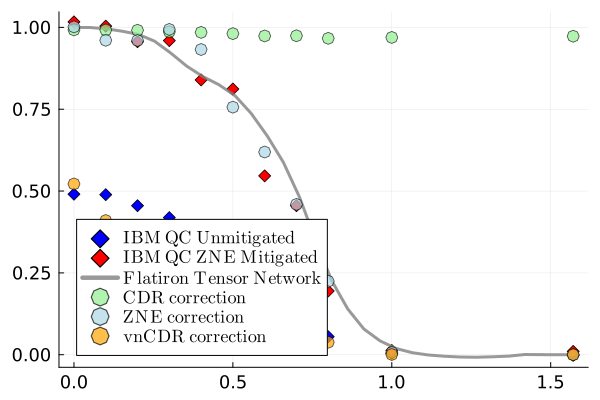

In [ ]:
scatter(mixed_angles, IBM_unmitigated_vals, label=L"\textrm{IBM\ QC\ Unmitigated}", marker=:diamond, 
            color=:blue, lw=2, 
            guidefontsize=16,
            tickfontsize=12,
            legendfontsize=12, ms=6)
scatter!(IBM_angles, IBM_mitigated_vals, label=L"\textrm{IBM\ QC\ ZNE\ Mitigated}", color="Red", ms=6, marker=:diamond)
plot!(tn_angles, tn_vals, label=L"\textrm{Flatiron\ Tensor\ Network}", color="grey", alpha=0.8, linewidth=3, ms=6)
# CPA / CDR
scatter!(mixed_angles, collect_cdr, label=L"\textrm{CDR\ correction}", color="lightgreen", linewidth=3,ms=6, marker=:o, alpha=0.7)
#ZNE
scatter!(mixed_angles, collect_zne, label=L"\textrm{ZNE\ correction}", color="lightblue",ms=6, marker=:o, alpha=0.7)
#vnCDR
scatter!(mixed_angles, collect_vncd, label=L"\textrm{vnCDR\ correction}", color="orange",ms=6, marker=:o, alpha=0.7)

# vnCDR is broken now